In [1]:
!pip install -q transformers datasets accelerate scikit-learn

In [2]:
import torch
import numpy as np

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

In [3]:
ds = load_dataset("stanfordnlp/imdb")

print(ds)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
# Select 500 positive and 500 negative training reviews
train_positive = ds["train"].filter(lambda x: x["label"] == 1).shuffle(seed=42).select(range(500))
train_negative = ds["train"].filter(lambda x: x["label"] == 0).shuffle(seed=42).select(range(500))

# Select 125 positive and 125 negative testing reviews
test_positive = ds["test"].filter(lambda x: x["label"] == 1).shuffle(seed=42).select(range(125))
test_negative = ds["test"].filter(lambda x: x["label"] == 0).shuffle(seed=42).select(range(125))

# Combine datasets
train_ds = train_positive.concatenate(train_negative) if hasattr(train_positive, "concatenate") else None

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [5]:
from datasets import concatenate_datasets

train_ds = concatenate_datasets([train_positive, train_negative])
test_ds = concatenate_datasets([test_positive, test_negative])

# Shuffle the combined datasets
train_ds = train_ds.shuffle(seed=42)
test_ds = test_ds.shuffle(seed=42)

print("Training samples:", len(train_ds))
print("Testing samples:", len(test_ds))

Training samples: 1000
Testing samples: 250


In [6]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [7]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

print("Tokenization completed!")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Tokenization completed!


In [8]:
train_ds = train_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

train_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(train_ds[0])

{'labels': tensor(0), 'input_ids': tensor([  101,  1996,  2986,  3459,  3685,  2039, 18412,  2023,  9410,  6925,
         1997,  1037,  3187,  7129,  2011,  2014,  2496, 11498, 20360,  1012,
         1999,  2755,  2045,  2024,  2062,  3980,  2084,  6998,  1999,  2023,
         2028,  1011, 11536,  6925,  1997,  7472,  1998,  4028,  1025,  1998,
         2144,  2057,  2024,  2069,  3024,  2007,  1996, 11537,  1005,  1055,
         2217,  1010,  3904,  1997,  2122,  3980,  2097,  2022,  4660,  1012,
         2023,  2003,  1996,  2828,  1997, 13258,  2008,  9023,  2000,  1996,
         1000,  2002,  2450,  1010,  2158,  5223,  2099,  1000,  4184,  1997,
         2637,  1012,  2004,  3591,  1010,  2009,  2003,  1996,  6925,  1997,
         2019,  7036,  2450,  2040,  2074,  6433,  2000,  2022,  1000,  3236,
         2039,  1000,  1999,  1037,  7472,  2007,  1037,  2496,  1010,  2152,
         1011,  6337,  4905,  1012,  2003,  2009,  2825,  2008,  2065,  1010,
         2016,  2018,  2025, 

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("BERT model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully!


In [10]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [11]:
training_args = TrainingArguments(
    output_dir="./bert_imdb_results",

    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    logging_steps=50,

    report_to="none",

    fp16=torch.cuda.is_available()
)

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_ds,
    eval_dataset=test_ds,

    compute_metrics=compute_metrics
)

print("Trainer initialized successfully!")

Trainer initialized successfully!


In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.587440,0.375888,0.848000,0.812950,0.904000,0.856061
2,0.303053,0.354071,0.844000,0.846774,0.840000,0.843373


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=250, training_loss=0.4524095458984375, metrics={'train_runtime': 102.6927, 'train_samples_per_second': 19.476, 'train_steps_per_second': 2.434, 'total_flos': 131555527680000.0, 'train_loss': 0.4524095458984375, 'epoch': 2.0})

In [14]:
results = trainer.evaluate()

print("\nModel Evaluation Results:")

for key, value in results.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.303053,0.375578,2,0.844000,0.811594,0.896000,0.851711



Model Evaluation Results:
eval_loss: 0.3756
eval_accuracy: 0.8440
eval_precision: 0.8116
eval_recall: 0.8960
eval_f1: 0.8517


In [15]:
predictions = trainer.predict(test_ds)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.88      0.79      0.84       125
    Positive       0.81      0.90      0.85       125

    accuracy                           0.84       250
   macro avg       0.85      0.84      0.84       250
weighted avg       0.85      0.84      0.84       250



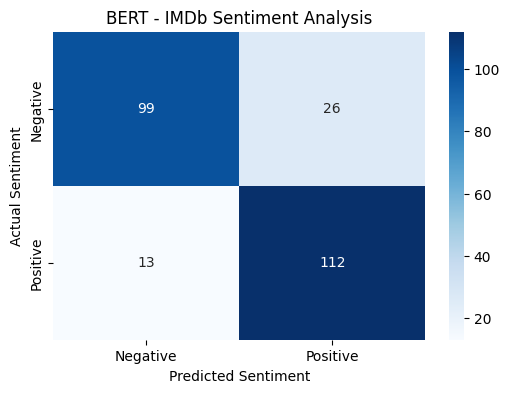

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("BERT - IMDb Sentiment Analysis")

plt.show()